In [1]:
import time
import pandas as pd
from langchain_community.llms import Ollama

In [8]:
# Specify the file path
file_path = "inflação/data/human/human_conciliado_220.csv"

# Load the dataset
df = pd.read_csv(
    file_path,
    sep='|', 
    parse_dates=['Date'],  # Converte a coluna Date para o tipo datetime
    dayfirst=True,          # Interpreta datas no formato DD/MM/YYYY
    encoding='utf-8'
)

# Display the first few rows of the dataset
print(df.head())

        Date  Model  Grade                                           Sentence
0 2009-09-02  human     -1  No médio prazo, o risco advém dos efeitos, cum...
1 2011-11-30  human     -1  Os preços livres aumentaram 7, 24% no período ...
2 2009-10-21  human      0  Nesse contexto, após um período de flexibiliza...
3 2013-04-17  human     -1  Considerada a série observada, o Nuci apresent...
4 2002-11-20  human     -1  Dados preliminares da Fecomércio mostram que o...


In [9]:
inicio = time.time()
llm = Ollama(model="gemma4:e4b", temperature=0)  # ajuste modelo/parametros conforme necessário
prompt = "Olá modelo como estás?"
resp_text = llm.invoke(prompt)
fim = time.time()
duracao = fim - inicio
print(f'duracao: {duracao}\n{resp_text}\n\n')

/tmp/ipykernel_788432/1081730878.py:2: LangChainDeprecationWarning: The class `Ollama` was deprecated in LangChain 0.3.1 and will be removed in 1.0.0. An updated version of the class exists in the `langchain-ollama package and should be used instead. To use it run `pip install -U `langchain-ollama` and import as `from `langchain_ollama import OllamaLLM``.
  llm = Ollama(model="gemma4:e4b", temperature=0)  # ajuste modelo/parametros conforme necessário


duracao: 6.164130687713623
Olá! Estou bem, obrigado/a por perguntar. 😊

Como posso ajudar você hoje? E você, como está?




In [35]:
promtp_prefix = """
DEFINIÇÃO DE OTIMISMO:
Ocorre quando as projeções indicam que a inflação ficará abaixo da meta ou dentro do intervalo de tolerância com folga. 
Isso pode sinalizar que o Banco Central vê espaço para reduzir juros ou manter uma política monetária mais acomodatícia. 

DEFINIÇÃO DE PESSIMISMO:
Ocorre quando as projeções apontam para inflação acima da meta ou próxima do teto do intervalo de tolerância. 
Isso sugere preocupação com pressões inflacionárias e pode justificar uma política monetária mais restritiva.

AVALIE A FRASE COMO
O para OTIMISTA
N para NEUTRA
P para PESSIMISTA
SUA RESPOSTA DEVE SER APENAS UMA DAS 3 LETRAS, SEM QUALQUER OUTRO TEXTO

A FRASE É:
"""

In [24]:
pred2num = {'O': 1, 'N': 0, 'P': -1}

In [37]:
for idx, r in df.iterrows():
    
    if r['Prediction'] in [0, 1, -1]: continue
    print(idx, end=' ')
    #print(r['Sentence'])        
    prompt = promtp_prefix + r['Sentence']
    #print(prompt)
    resp_text = llm.invoke(prompt)
    print(resp_text)
    #r['Prediction'] = resp_text
    df.loc[idx, 'Prediction'] = pred2num[resp_text]
    #break


105 O
106 P
107 N
108 O
109 O
110 N
111 O
112 P
113 N
114 N
115 P
116 P
117 N
118 O
119 O
120 O
121 N
122 N
123 O
124 N
125 N
126 N
127 N
128 N
129 O
130 N
131 N
132 N
133 N
134 N
135 P
136 N
137 N
138 N
139 N
140 O
141 P
142 N
143 P
144 N
145 P
146 N
147 O
148 N
149 N
150 O
151 O
152 O
153 N
154 N
155 N
156 N
157 P
158 O
159 N
160 O
161 N
162 N
163 N
164 N
165 O
166 P
167 N
168 N
169 N
170 P
171 N
172 P
173 N
174 O
175 N
176 O
177 O
178 O
179 P
180 P
181 P
182 P
183 P
184 P
185 P
186 P
187 N
188 O
189 O
190 N
191 N
192 P
193 N
194 P
195 P
196 N
197 N
198 O
199 O
200 O
201 N
202 P
203 P
204 N
205 P
206 O
207 P
208 P
209 N
210 P
211 P
212 N
213 N
214 O
215 P
216 O
217 N
218 O
219 O


In [38]:
df.rename(columns={'Prediction': 'gemma4:e4b'}, inplace=True)
df.head()

,Date,Model,Grade,Sentence,gemma4:e4b
0,2009-09-02,human,-1,"No médio prazo, o risco advém dos efeitos, cum...",-1
1,2011-11-30,human,-1,"Os preços livres aumentaram 7, 24% no período ...",0
2,2009-10-21,human,0,"Nesse contexto, após um período de flexibiliza...",0
3,2013-04-17,human,-1,"Considerada a série observada, o Nuci apresent...",0
4,2002-11-20,human,-1,Dados preliminares da Fecomércio mostram que o...,0


In [39]:
from sklearn.metrics import classification_report

# Remove valores nulos caso haja linhas não processadas
df_clean = df.dropna(subset=['Grade', 'gemma4:e4b'])

# Garante que as colunas estejam no mesmo formato de texto
y_true = df_clean['Grade'].astype(str)
y_pred = df_clean['gemma4:e4b'].astype(str)

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

          -1       0.60      0.59      0.60        61
           0       0.64      0.60      0.62       111
           1       0.55      0.65      0.60        48

    accuracy                           0.61       220
   macro avg       0.60      0.61      0.60       220
weighted avg       0.61      0.61      0.61       220



In [46]:
from sklearn.metrics import ConfusionMatrixDisplay

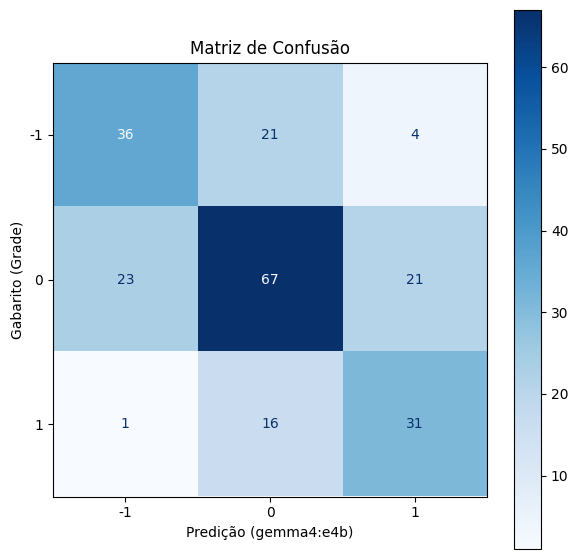

In [47]:
# Plota a matriz diretamente com Matplotlib
fig, ax = plt.subplots(figsize=(7, 7))

ConfusionMatrixDisplay.from_predictions(
    y_true, 
    y_pred, 
    cmap=plt.cm.Blues, 
    ax=ax,
    colorbar=True
)

plt.title('Matriz de Confusão')
plt.xlabel('Predição (gemma4:e4b)')
plt.ylabel('Gabarito (Grade)')
plt.show()

In [ ]:
messages = []
seen_sentences = set()
for (date, sentence), ann in existing.items():
    if ann['model'] == 'human' and sentence not in seen_sentences:
        seen_sentences.add(sentence)
        letter = REVERSE_GRADE_MAP[ann['grade']]
        messages.append({"role": "user", "content": PROMPT + sentence})
        messages.append({"role": "assistant", "content": letter})
